## Week10 - Reinforcement Learning With Actor-Critic Method

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. This notebook demonstrates how to implement the Actor-Critic algorithm using TensorFlow to solve the classic CartPole-v1 control problem from OpenAI Gym. 

In [1]:
import numpy as np
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import layers
import random
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd
from IPython import display
from IPython.display import clear_output

np.bool8 = np.bool_

/Users/ellamousavi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def plot_score_epsilon(episode_rewards, epsilons = None):
    clear_output(wait=True)
    plt.style.use('ggplot')
    plt.rc('font', size=10)
    window=50

    plt.figure(figsize=(8, 4))
    plt.title('Total Rewards')

    rolling_mean = pd.Series(episode_rewards).rolling(window).mean()
    std = pd.Series(episode_rewards).rolling(window).std()
    plt.plot(episode_rewards, label='Total Reward', linewidth=1)
    plt.plot(rolling_mean, label='Rolling Mean', linewidth=2)
    plt.fill_between(range(len(episode_rewards)), rolling_mean - std, rolling_mean + std, color='violet', alpha=0.6)

    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid('on')
    plt.show()

    if epsilons is not None:
        plt.figure(figsize=(8, 4))
        plt.title('Total Rewards')
        plt.plot(epsilons, linewidth=1)
        plt.xlabel("Episode")
        plt.ylabel("Epsilon")
        plt.title("Epsilon Decay Over Time")
        plt.grid('on')
        plt.show()


# Actor Critic

In this notebook, we implement the **Actor-Critic algorithm** for the CartPole environment using TensorFlow and Keras. Actor-Critic methods combine the strengths of both **policy-based** and **value-based** reinforcement learning algorithms.

Unlike REINFORCE, which updates the policy at the end of each episode using Monte Carlo estimates, Actor-Critic updates the actor and critic **at each time step** using a **temporal-difference (TD) bootstrapped estimate**, making it more sample-efficient and stable.

The actor is responsible for selecting actions based on the current policy, while the critic evaluates the action taken by estimating the value function. The actor is updated using the TD error, which is the difference between the estimated value and the actual reward received, while the critic is updated using the TD error to improve its value function approximation.



In [10]:
env = gym.make("CartPole-v1", render_mode="human")
state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

In [4]:
# Hyperparameters
gamma = 0.99
learning_rate = 0.001
num_episodes = 1000
episode_rewards = []

### **1. Initialize the Actor and Critic networks**

The algorithm consists of two main components:
1. **Actor** $\pi_\theta(a|s)$ : The policy network that selects actions based on the current state.
2. **Critic** $V_w(s)$ : The value network that estimates the value of the current state-action pair.

In [11]:
# Initialize models and optimizers
actor = tf.keras.Sequential([
    layers.Input(shape=(state_dim,)),
    layers.Dense(24, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(n_actions, activation='linear')
])

critic = tf.keras.Sequential([
    layers.Input(shape=(state_dim,)),
    layers.Dense(24, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='linear')])

actor_optimizer = tf.keras.optimizers.Adam(learning_rate)
critic_optimizer = tf.keras.optimizers.Adam(learning_rate)

### **2. For each episode:**

#### a. **Reset the environment**

Start from an initial state $s_0$.


#### b. **Repeat for each step of the episode:**

1. **Choose an action**  
   Sample an action $a_t \sim \pi_\theta(a_t | s_t)$ from the actor's policy output.

2. **Take the action and observe the outcome**  
   Execute action $a_t$, receive reward $r_t$, next state $s_{t+1}$, and done flag.

3. **Compute the TD target**  
   
   $y_t = r_t + \gamma V_w(s_{t+1})$
   

4. **Compute the TD error (advantage)**  
   
   $A_t = y_t - V_w(s_t)$
   

5. **Update the Critic**  
   Minimize the squared TD error:
   
   $L(w) = (y_t - V_w(s_t))^2$
   

6. **Update the Actor**  
   Use the TD error as an advantage estimate to update the policy:
   
   $\nabla_\theta J(\theta) = \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot A_t$
   

7. **Advance to next state**  
   Set $s_t \leftarrow s_{t+1}$ and repeat until the episode ends.


### **3. Repeat for multiple episodes**

Train the networks until the policy converges or a sufficient performance threshold is reached.

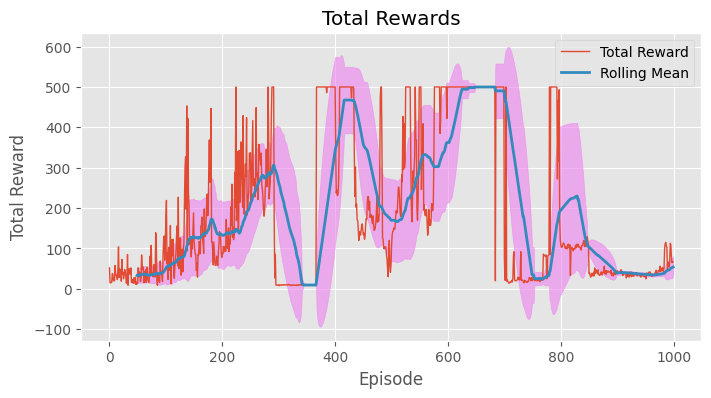

: 

In [ ]:
for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0

    done = False
    while not done:

        # Get Action
        logits = actor(tf.convert_to_tensor([state], dtype=tf.float32))
        action_probs = tf.nn.softmax(logits)
        action = np.random.choice(n_actions, p=action_probs.numpy()[0])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Training Step
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        next_state_tensor = tf.convert_to_tensor([next_state], dtype=tf.float32)
        action_tensor = tf.convert_to_tensor([action], dtype=tf.int32)
        reward_tensor = tf.convert_to_tensor(reward, dtype=tf.float32)

        # Critic update
        with tf.GradientTape() as tape:
            target = reward_tensor + gamma * critic(next_state_tensor)[0, 0] * (1. - float(done))
            value = critic(state_tensor)[0, 0]
            critic_loss = tf.square(target - value)
        grads = tape.gradient(critic_loss, critic.trainable_variables)
        critic_optimizer.apply_gradients(zip(grads, critic.trainable_variables))

        # Actor update
        with tf.GradientTape() as tape:
            logits = actor(state_tensor)
            action_probs = tf.nn.softmax(logits)
            log_prob = tf.math.log(action_probs[0, action_tensor[0]])
            advantage = target - value
            actor_loss = -log_prob * advantage
        grads = tape.gradient(actor_loss, actor.trainable_variables)
        actor_optimizer.apply_gradients(zip(grads, actor.trainable_variables))

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)
    plot_score_epsilon(episode_rewards)